In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
import os


In [3]:
os.chdir("/home/yogeshwar10/Data Science Projects/satellite-property-valuation")

In [4]:
df = pd.read_csv(r"data/raw/train.csv")
df_test = pd.read_csv(r"data/raw/test.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             16209 non-null  int64  
 1   date           16209 non-null  object 
 2   price          16209 non-null  int64  
 3   bedrooms       16209 non-null  int64  
 4   bathrooms      16209 non-null  float64
 5   sqft_living    16209 non-null  int64  
 6   sqft_lot       16209 non-null  int64  
 7   floors         16209 non-null  float64
 8   waterfront     16209 non-null  int64  
 9   view           16209 non-null  int64  
 10  condition      16209 non-null  int64  
 11  grade          16209 non-null  int64  
 12  sqft_above     16209 non-null  int64  
 13  sqft_basement  16209 non-null  int64  
 14  yr_built       16209 non-null  int64  
 15  yr_renovated   16209 non-null  int64  
 16  zipcode        16209 non-null  int64  
 17  lat            16209 non-null  float64
 18  long  

In [6]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [20]:
# Handling date column
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.day_of_week
df = df.drop(columns=["date"]) #For now using month and year only as features. Later could use is_first_week_of_month etc too if possible

# Handling zip code
df = df.drop(columns=["zipcode"]) #As lat and long encode the information better. Later can one-hot encode, but that will create many columns (tree based models might handle, but not Linear Regressors)

#Extracting from yr_renovated
df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)

df

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,lat,long,sqft_living15,sqft_lot15,year,month,day,day_of_week,is_renovated
0,9117000170,268643,4,2.25,1810,9240,2.0,0,0,3,...,0,47.4362,-122.187,1660,9240,2015,5,5,1,0
1,6700390210,245000,3,2.50,1600,2788,2.0,0,0,4,...,0,47.4034,-122.187,1720,3605,2014,7,8,1,0
2,7212660540,200000,4,2.50,1720,8638,2.0,0,0,3,...,0,47.2704,-122.313,1870,7455,2015,1,15,3,0
3,8562780200,352499,2,2.25,1240,705,2.0,0,0,3,...,0,47.5321,-122.073,1240,750,2015,4,27,0,0
4,7760400350,232000,3,2.00,1280,13356,1.0,0,0,3,...,0,47.3715,-122.074,1590,8071,2014,12,5,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16204,5272200045,378000,3,1.50,1000,6914,1.0,0,0,3,...,0,47.7144,-122.319,1000,6947,2014,11,13,3,0
16205,9578500790,399950,3,2.50,3087,5002,2.0,0,0,3,...,0,47.2974,-122.349,2927,5183,2014,11,11,1,0
16206,7202350480,575000,3,2.50,2120,4780,2.0,0,0,3,...,0,47.6810,-122.032,1690,2650,2014,9,30,1,0
16207,1723049033,245000,1,0.75,380,15000,1.0,0,0,3,...,0,47.4810,-122.323,1170,15000,2014,6,20,4,0


In [21]:
df["log_price"] = np.log(df["price"])

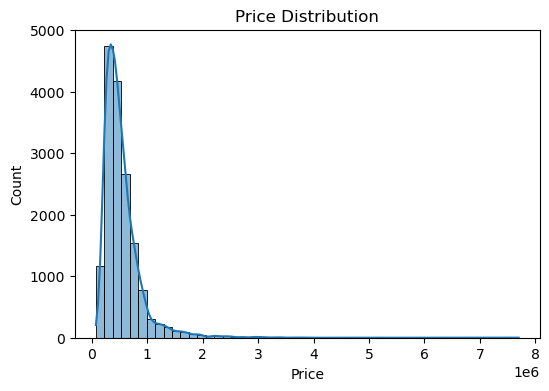

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

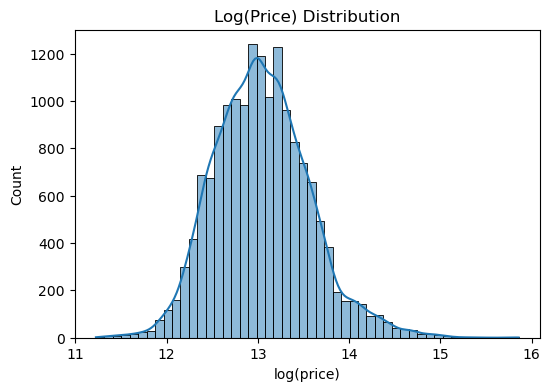

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(np.log(df["price"]), bins=50, kde=True)
plt.title("Log(Price) Distribution")
plt.xlabel("log(price)")
plt.ylabel("Count")
plt.show()

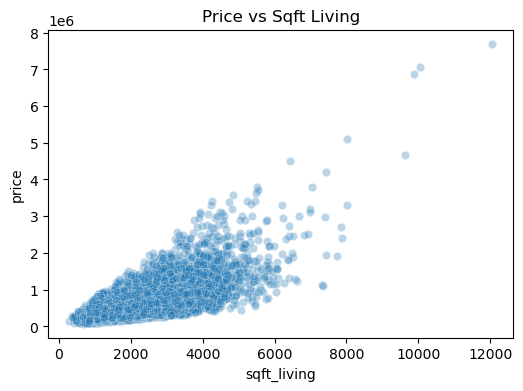

In [24]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["sqft_living"], y=df["price"], alpha=0.3)
plt.title("Price vs Sqft Living")
plt.xlabel("sqft_living")
plt.ylabel("price")
plt.show()

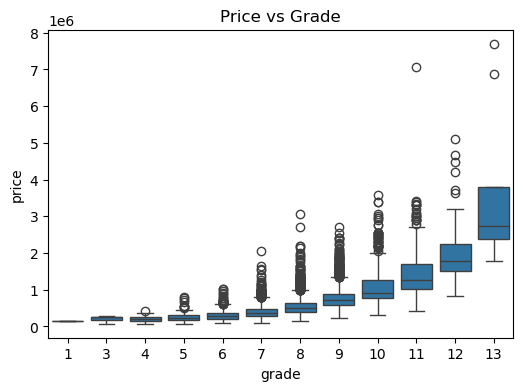

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["grade"], y=df["price"])
plt.title("Price vs Grade")
plt.xlabel("grade")
plt.ylabel("price")
plt.show()


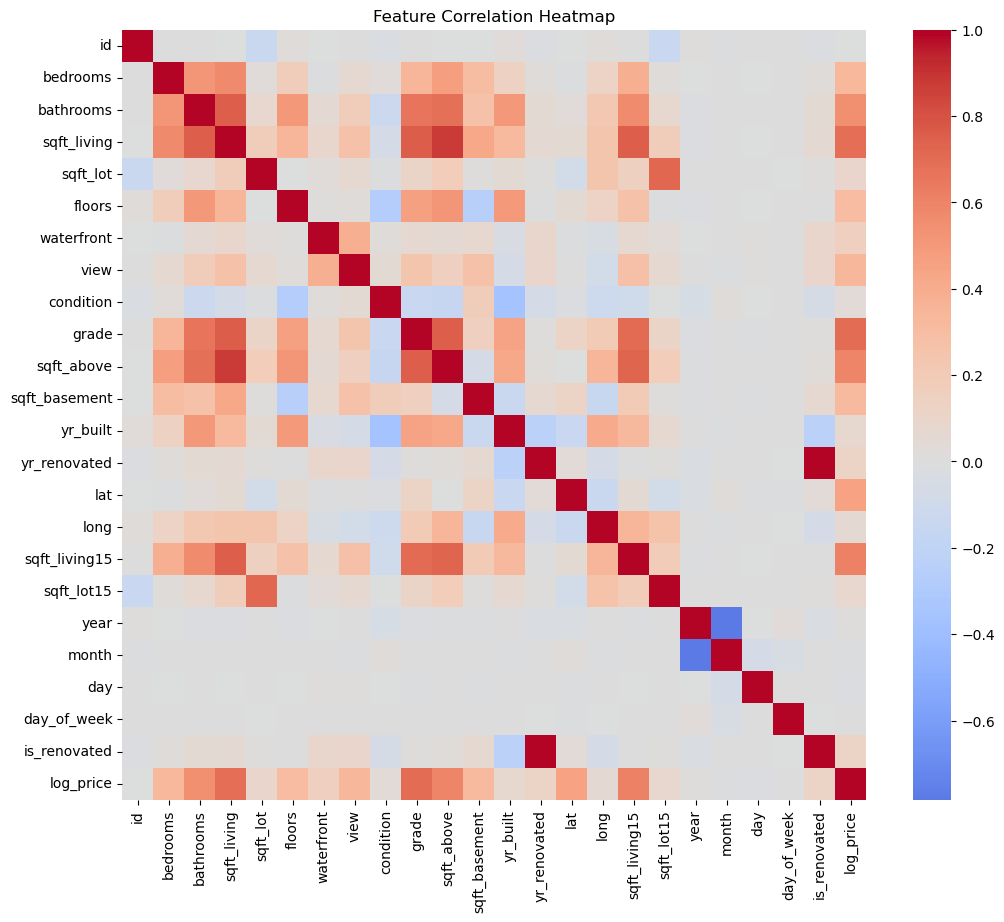

In [26]:
plt.figure(figsize=(12,10))
corr = df.drop(columns=["price"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [27]:
X = df.drop(columns=["price", "log_price"])
y = df["log_price"]

In [28]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [29]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_val)


In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

In [36]:
from sklearn.metrics import r2_score, root_mean_squared_error

def evaluate(y_true_log, y_pred_log):
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    rmse = root_mean_squared_error(y_true, y_pred,)
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

print("Linear (RMSE and R2) :", evaluate(y_val, y_pred_lr))
print("RF (RMSE and R2) :", evaluate(y_val, y_pred_rf))


Linear (RMSE and R2) : (176183.76281246258, 0.7526411504248601)
RF (RMSE and R2) : (135167.43571131286, 0.8544072196433146)
